# Reflection Spectra over Frequencies for Radar Design

In this example, we do a random search of LF and benchmark against the results in Fig. 6 in Reference [1].

[1] Eric Michielssen, Jean-Michel Sajer, S. Ranjithan, and Raj Mittra. [Design of lightweight, broad-band microwave absorbers using genetic algorithms](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=238519&casa_token=cAzTLiuvjPcAAAAA:iW8Ema9V9aE9lUAGOst4mGaeFeh45hGqOAJY1-ieAXdYcAqUmrNo1d3PpHUrecssvVvZzWK6rg&tag=1). *IEEE Transactions on Microwave Theory and Techniques*, vol. 41, no. 6, pp. 1024–1031, 1993.

First, the required packages are imported.

In [101]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np

import jaxlayerlumos as jll
import jaxlayerlumos.utils_materials as jll_utils_materials
import jaxlayerlumos.utils_units as jll_utils_units

We define frequencies from 0.1 GHz to 10 GHz and an incidence angle 0

In [102]:
freq_range = (0.2, 2)
inc_angle = 0.0

frequencies = jnp.linspace(freq_range[0] * jll_utils_units.get_giga(), freq_range[1] * jll_utils_units.get_giga(), 1000)
frequencies_in_ghz = np.array(frequencies) / jll_utils_units.get_giga()

We generate random radar designs of five layers.  Materials are chosen from table 1, which are integers from 1 to 16.  For total thicknesses, we target total thicknesses less than 5 mm.

This defines the function to generate random designs.

In [103]:
import numpy as np

def generate_random_designs(num_random_designs,
                            n_layers=5,
                            min_total_thickness_mm=0.0,
                            max_total_thickness_mm=5.0,
                            min_layer_thickness_mm=0.01,
                            max_layer_thickness_mm=1.5,
                            seed=None,
                            batch_size=10000):
    """
    Faster generator using vectorized sampling and filtering.
    """
    rng = np.random.default_rng(seed)
    designs = []

    while len(designs) < num_random_designs:
        # 1) Sample a batch of candidates at once
        materials_batch = rng.integers(1, 17, size=(batch_size, n_layers))
        thickness_batch = rng.uniform(min_layer_thickness_mm,
                                      max_layer_thickness_mm,
                                      size=(batch_size, n_layers))

        # 2) Compute total thickness for each candidate
        totals = thickness_batch.sum(axis=1)

        # 3) Apply total thickness constraints
        mask = (totals >= min_total_thickness_mm) & (totals <= max_total_thickness_mm)

        valid_materials = materials_batch[mask]
        valid_thicknesses = thickness_batch[mask]
        valid_totals = totals[mask]

        # 4) Add valid designs until we hit the target count
        for mats, thicks, tot in zip(valid_materials, valid_thicknesses, valid_totals):
            designs.append({
                "materials_data": mats,
                "thicknesses_mm": thicks,
                "total_thickness_mm": float(tot)
            })
            if len(designs) >= num_random_designs:
                break

    return designs



Here we specify the number of random designs and constraints and generate them

In [104]:
num_random_designs = 200
n_layers = 5
seed = 42 # so we can reproduce results
min_total_thickness_mm=2.0,
max_total_thickness_mm=5.5,
min_layer_thickness_mm=0.3,
max_layer_thickness_mm=1.5,

random_designs = generate_random_designs(
    num_random_designs,
    n_layers,
    min_total_thickness_mm,
    max_total_thickness_mm,
    min_layer_thickness_mm,
    max_layer_thickness_mm,
    seed=42
)

for i, d in enumerate(random_designs[:3]):  # print first 3 designs
    print(f"Design {i}")
    print("  materials_data:", d["materials_data"])
    print("  thicknesses_mm:", d["thicknesses_mm"])
    print("  total_thickness_mm:", d["total_thickness_mm"])
    print()

Design 0
  materials_data: [14  2 12  4  2]
  thicknesses_mm: [0.90396837 0.48680007 1.32529701 1.11094912 1.06552274]
  total_thickness_mm: 4.892537311104006

Design 1
  materials_data: [ 9 16 12 13 12]
  thicknesses_mm: [0.5643974  0.48379116 1.34763177 0.51529674 0.38846216]
  total_thickness_mm: 3.299579232742248

Design 2
  materials_data: [13  9  3 14  8]
  thicknesses_mm: [1.05072624 1.14521191 0.44354689 0.54823129 1.24651655]
  total_thickness_mm: 4.4342328829572955



Now, we run the simulations

In [105]:
Rs_in_db = []

for i, design in enumerate(random_designs):
    materials_data = design["materials_data"]      # array of ints 1–16
    thicknesses_mm = design["thicknesses_mm"]      # key name fixed

    # Build materials list: Air | layers | PEC
    materials = ["Air"] + list(materials_data) + ["PEC"]

    # Convert mm -> m (assuming get_milli() = 1e-3)
    thicknesses = jnp.array(
        [0.0]
        + [t * jll_utils_units.get_milli() for t in thicknesses_mm]
        + [0.0]
    )

    # Get eps, mu and compute reflection
    eps_stack, mu_stack = jll_utils_materials.get_eps_mu(materials, frequencies)
    R_TE, _, R_TM, _ = jll.stackrt_eps_mu(
        eps_stack, mu_stack, thicknesses, frequencies, inc_angle
    )
    R = (R_TE + R_TM) / 2.0
    R_in_db = 10 * jnp.log10(R).squeeze()
    max_R_value = float(np.max(R_in_db))

    # Print (optional)
    # print(f"LF{i + 1}: max(R_in_db) {max_R_value:.2f}")

    # Store in list
    Rs_in_db.append(R_in_db)

    # Store directly inside the design dict
    design["max_R_in_db"] = max_R_value


Determine which designs are on the Pareto frontier

In [106]:
def pareto_frontier(thickness, reflection):
    """
    thickness: array-like, lower is better
    reflection: array-like, lower (more negative) is better
    Returns a boolean mask for Pareto-optimal points.
    """
    points = np.column_stack([thickness, reflection])
    is_pareto = np.ones(points.shape[0], dtype=bool)

    for i, p in enumerate(points):
        if is_pareto[i]:
            # Points that dominate p
            dominated_by = np.all(points <= p, axis=1) & np.any(points < p, axis=1)
            if np.any(dominated_by):
                is_pareto[i] = False

    return is_pareto

# Extract thickness and reflection arrays for random designs
random_thickness = np.array([d["total_thickness_mm"] for d in random_designs])
random_reflection = np.array([d["max_R_in_db"] for d in random_designs])

# Compute Pareto mask
pareto_mask = pareto_frontier(random_thickness, random_reflection)

# Indices of Pareto-optimal designs
pareto_indices = np.where(pareto_mask)[0]

pareto_indices

array([ 45,  67,  82,  98, 152])

Plot and compare Pareto frontier to Michelson paper.

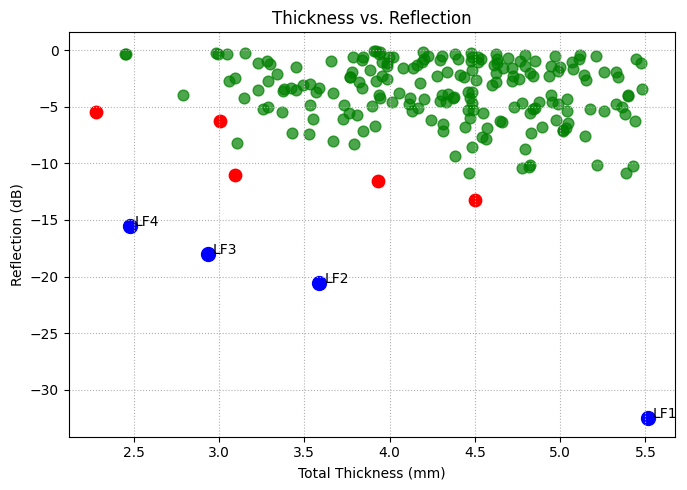

In [107]:
# Data
total_thickness = [5.514, 3.588, 2.934, 2.478]
ref_R_in_db = [-32.52, -20.60, -18.03, -15.50]

random_total_thickness = np.array([d["total_thickness_mm"] for d in random_designs])
random_max_R = np.array([d["max_R_in_db"] for d in random_designs])


# Make scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(total_thickness, ref_R_in_db, s=100, color='blue')

# Label points (LF1–LF4)
for i, (x, y) in enumerate(zip(total_thickness, ref_R_in_db)):
    plt.text(x + 0.03, y, f"LF{i+1}", fontsize=10)

# Plot random designs
plt.scatter(random_total_thickness, random_max_R, color='green', s=60, alpha=0.7, label="Random Designs")

# Plot Pareto frontier points (red)
plt.scatter(random_total_thickness[pareto_mask],
            random_max_R[pareto_mask],
            s=80, color='red', label="Pareto Designs")

plt.xlabel("Total Thickness (mm)")
plt.ylabel("Reflection (dB)")
plt.title("Thickness vs. Reflection")
plt.grid(True, linestyle=":")

plt.tight_layout()
plt.show()


The results of reflection spectra of Pareto optimal stuctures over frequencies are plotted. They are plotted from smallest thickness to largest thickness.

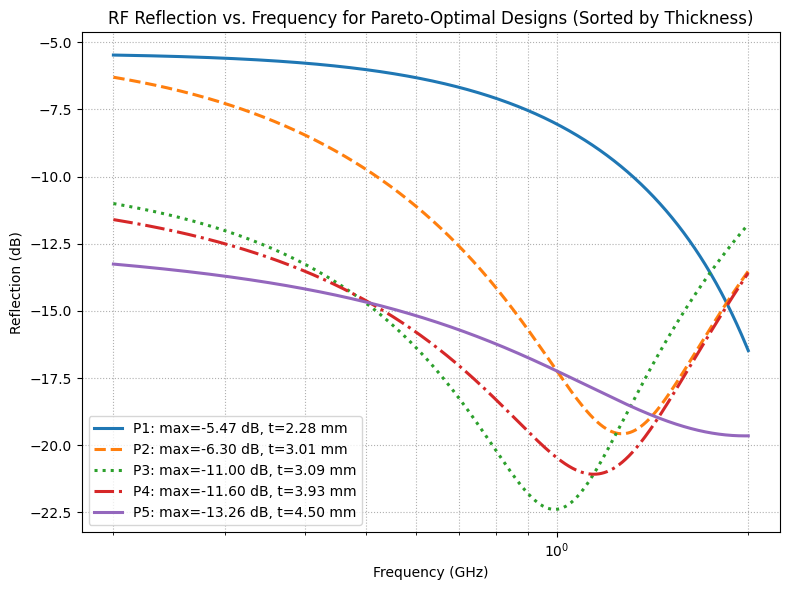

In [108]:
# --- Sort Pareto indices by total thickness ---
sorted_pareto_indices = sorted(
    pareto_indices,
    key=lambda idx: random_total_thickness[idx]
)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

line_styles = ['-', '--', ':', '-.']
freqs = np.array(frequencies_in_ghz)

# Plot only Pareto-optimal designs (sorted by thickness)
for count, idx in enumerate(sorted_pareto_indices):

    R_in_db = Rs_in_db[idx]
    R_np = np.array(R_in_db)

    thickness_val = random_total_thickness[idx]   # total thickness (mm)
    maxR_val = np.max(R_np)                       # max reflection (dB)

    ax.semilogx(
        freqs,
        R_np,
        line_styles[count % len(line_styles)],
        linewidth=2.2,
        label=f"P{count+1}: max={maxR_val:.2f} dB, t={thickness_val:.2f} mm"
    )

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflection (dB)")
ax.set_title("RF Reflection vs. Frequency for Pareto-Optimal Designs (Sorted by Thickness)")
ax.grid(True, which="both", linestyle=":")

plt.legend()
plt.tight_layout()
plt.show()


In [109]:
random_designs

[{'materials_data': array([14,  2, 12,  4,  2]),
  'thicknesses_mm': array([0.90396837, 0.48680007, 1.32529701, 1.11094912, 1.06552274]),
  'total_thickness_mm': 4.892537311104006,
  'max_R_in_db': -6.753306502563077},
 {'materials_data': array([ 9, 16, 12, 13, 12]),
  'thicknesses_mm': array([0.5643974 , 0.48379116, 1.34763177, 0.51529674, 0.38846216]),
  'total_thickness_mm': 3.299579232742248,
  'max_R_in_db': -1.2154666479491376},
 {'materials_data': array([13,  9,  3, 14,  8]),
  'thicknesses_mm': array([1.05072624, 1.14521191, 0.44354689, 0.54823129, 1.24651655]),
  'total_thickness_mm': 4.4342328829572955,
  'max_R_in_db': -2.3557208206053346},
 {'materials_data': array([ 9,  6,  3, 15, 13]),
  'thicknesses_mm': array([1.41550224, 0.87178646, 1.25040597, 0.68328014, 1.14388073]),
  'total_thickness_mm': 5.364855537887799,
  'max_R_in_db': -5.007558038920328},
 {'materials_data': array([11,  7, 14,  9,  8]),
  'thicknesses_mm': array([0.96866455, 1.3118531 , 1.23108132, 0.6409630